Nathaniel Linden-Santangeli 2025

### Prior predictive elicitation for AMPK models

##### Background

Inference for the AMPK models with wide relatively un-informed priors is challenging, with posteriors often failing to capture the appropriate sigmoidal responses seen in the data (as of 1/16/2025). The `../test_models_and_mass_conservation/explore_sensor_model.ipynb` notebook uses a simple sensor model with a time-dependent phosphorylation rate to determine what features of the phosphorylation rate are needed to achieve sigmoidal sensor responses. In particular we found the following

1. The initial phosphorylation rate must be zero (or very small relative to the dephosphorylation rate) to achieve the slow initial rise in the sensor response.
2. Increasing phosphorylation rates give rise to the increasing slope of the sensor response after the initial slow activation.
3. Increased dephosphorylation rates can slow down sensor activation, but also decrease the steady-state response. Higher phosphorylation rates can counteract this effect, but they speed of the overall response.

Therefore, we need to assign priors to the AMPK models that lead to slow initial activation, followed by a rapid increase in activation, and a steady-state response that fully activates the sensor.

##### Direct prior elicitation - maximum entropy priors

Direct elicitation aims to assign prior parameters such that the prior mass is between specified ranges. See [Preliz - Direct elicitation in 1D](https://preliz.readthedocs.io/en/latest/examples/Direct_elicitation_in_1D.html) for details on the approach. We specified the bounds by multiplying literature values of each parameter by a factor of 1e4 and 1e-3 (or smh similar).

##### Predictive prior elicitation
We previously used *maximum entropy* elicitation to find parameter for prior densities such that the prior mass was between specified ranges. See [Preliz - Direct elicitation in 1D](https://preliz.readthedocs.io/en/latest/examples/Direct_elicitation_in_1D.html) for details on the approach. We specified the bounds by multiplying literature values of each parameter by a factor of 1e4 and 1e-3 (or smh similar). However this approach led to priors that are far too wide and sometimes place little to know prior mass on the appropriate parameter ranges.

**Predictive** prior elicitation is based on the idea of choosing prior parameters such that the prior predictive density *makes sense* or contains predictions that agree with our expectations of the model. See [Preliz - predictive elicitation](https://preliz.readthedocs.io/en/latest/examples/predictive_elicitation.html) for more details.

This reference [Prior knowledge elicitation: The past, present, and future](https://projecteuclid.org/journals/bayesian-analysis/advance-publication/Prior-Knowledge-Elicitation-The-Past-Present-and-Future/10.1214/23-BA1381.full) provides a nice overview of the concepts of prior elicitation

##### Goals of this notebook
1. Set up predictive elicitation for the AMPK models such that we are able to tune prior parameters to achieve prior predictive densities that are reasonable.
2. Obtain refined prior parameters for the AMPK models that lead to reasonable prior predictive densities which can be justified by the fact that they provide reasonable *a priori* predictions of the sensor response.

In [95]:
# imports
import jax
import jax.numpy as jnp
import numpy as np
import diffrax as dfrx
import equinox as eqx
import pymc as pm
from pytensor.link.jax.dispatch import jax_funcify
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
import sys, json
import matplotlib.pyplot as plt
import seaborn as sns
import met_brewer as mb

sys.path.append("../")
from utils import *
from pymc_jax_ode import *

sys.path.append("../models/")

# tell jax to use 64bit floats
jax.config.update('jax_platform_name', 'cpu')
jax.config.update("jax_enable_x64", True)

plt.style.use("~/.matplotlib/stylelib/custom.mplstyle")

savedir = '../../../results/param_est/prior_predictive/'

In [96]:
from MM_single_diffrax import *

MM_info = json.load(open('../models/MM_single.json'))

# get initial conditions
y0_MM = list(MM_info['init_conds'].values())

# deal with getting AMPKAR idxs
state_names_MM = list(MM_info["init_conds"].keys()) # MM
ampkar_states_MM = MM_info['ampkar_states']
pampkar_states_MM = MM_info['pampkar_states']
ampkar_idxs_MM = [state_names_MM.index(item) for item in ampkar_states_MM]
pampkar_idxs_MM = [state_names_MM.index(item) for item in pampkar_states_MM]

# get metabolism params - same for both models
metab_params = json.load(open('../models/metabolism_params_Coccimiglio.json'))
basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values())

# cosrtuct ODE rhs objects
MM_rhs = dfrx.ODETerm(MM_single(*basal_params))
MM_rhs_stress = dfrx.ODETerm(MM_single(*stress_params))

# load data
cyto_data, cyto_std, cyto_times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz')
lyso_data, lyso_std, lyso_times = load_data('../../../Schmitt_et_al_2022_data/fig_2b_lyso.npz')
mito_data, mito_std, mito_times = load_data('../../../Schmitt_et_al_2022_data/fig_2c_mito.npz')

cyto_data = cyto_data.reshape((1, len(cyto_data)))
lyso_data = lyso_data.reshape((1, len(lyso_data)))
mito_data = mito_data.reshape((1, len(mito_data)))
cyto_std = cyto_std.reshape((1, len(cyto_std)))
lyso_std = lyso_std.reshape((1, len(lyso_std)))
mito_std = mito_std.reshape((1, len(mito_std)))

cyto_times_fine = np.linspace(cyto_times.min()*60, cyto_times.max()*60, num=1000)
cyto_data_fine= np.interp(cyto_times_fine, cyto_times*60, cyto_data[0]).reshape((1, len(cyto_times_fine)))
cyto_std_fine= np.interp(cyto_times_fine, cyto_times*60, cyto_std[0]).reshape((1, len(cyto_times_fine)))

# solver params
atol, rtol, evnt_atol, evnt_rtol = 1e-6, 1e-6, 1e-12, 1e-12
pcoeff, icoeff = 0.3, 0.4
dt0=1e-10
tmax_init = 1e3

ca_index = 4
ca_stress = jnp.array([0.25,])

# define simulator funcs
@jax.jit
def MM_sim(params):
    sol_stressed, _ = solve_traj_timeDepCaMKK(MM_rhs, MM_rhs_stress, y0_MM, ca_stress, ca_index, params, cyto_times_fine, tmax_init=tmax_init, rtol=rtol, atol=atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=0.0, dt0=1e-10)

    # compute delta pAMPKAR/AMPKAR_tot
    AMPKAR_stressed = sol_stressed[jnp.array(ampkar_idxs_MM), :].sum(axis=0)
    pAMPKAR_stressed = sol_stressed[jnp.array(pampkar_idxs_MM), :].sum(axis=0)
    result = pAMPKAR_stressed / AMPKAR_stressed
        
    return jnp.reshape(result, (1, len(result)))

# Pytensor Ops
# construct PyTensor Op for simulator
def sol_op_jax_MM(*params):
    return MM_sim(params)
sol_op_jax_jitted_MM = eqx.filter_jit(sol_op_jax_MM)

def vjp_sol_op_jax_MM(gz, *params):
        _, vjp_fn = jax.vjp(sol_op_jax_MM, *params)
        return vjp_fn(gz)
jp_sol_op_jax_jitted_MM = eqx.filter_jit(vjp_sol_op_jax_MM)

# using Jax-based sampler, so we do not need the Pytensor ops for the grads
vjp_sol_op_MM = VJPSolOp(jp_sol_op_jax_jitted_MM)
sol_op_MM = SolOp(sol_op_jax_jitted_MM, vjp_sol_op_MM)

@jax_funcify.register(SolOp)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax_MM

@jax_funcify.register(VJPSolOp)
def sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax_MM

#### Direct prior elicitation using Preliz Maxent

First we elicit priors from the bounds that are specified in the model_info files under the `param_bounds_original` key. These bounds are based on the literature values for the parameters

We choose priors such that 90% of the prior mass is between the bounds

In [97]:
model = 'MM_single'

prob_mass = 0.9 # mass between bounds
prior_params = {}

model_info_file = f'../models/{model}.json'
with open(model_info_file, 'r') as file:
        model_info = json.load(file)

bounds = model_info['param_bounds_original']
for param in model_info['params']:
        if len(bounds[param]) > 0:
            result = pz.maxent(pz.LogNormal(), lower=bounds[param][0], 
                                upper=bounds[param][1], mass=prob_mass, plot=False)
            mu = result.params[0]
            sigma = result.params[1]

            # store in a model_info dictionary
            prior_params[param] = {'mu': mu, 'sigma': sigma}
        
        if len(bounds[param]) == 0:
            prior_params[param] = {}

#### PyMC models
Build the PyMC models for the MA and MM models, with lognormal priors on the parameters. 

**Notes:**

- To better attribute variation in the predictions to variation in the params, we will artificially set the variance of the likelihood to be very small. This will allow us to see how the prior predictive density changes as we change the parameters and will eliminate the noise added from sampling from the likelihood.
- We only include locally identifiable params

In [98]:
# orig. pymc models
std_mult = 0.001 # multiplier to reduce likelihood std

def construct_pm_model_MM(kOffAMP_mu=prior_params['kOffAMP']['mu'],
            kOffAMP_sigma=prior_params['kOffAMP']['sigma'],
            kOffADP_mu=prior_params['kOffADP']['mu'],
            kOffADP_sigma=prior_params['kOffADP']['sigma'],
            kOffATP_mu=prior_params['kOffATP']['mu'],
            kOffATP_sigma=prior_params['kOffATP']['sigma'],
            Km_CaMKK_mu=prior_params['KmCaMKK']['mu'],
            Km_CaMKK_sigma=prior_params['KmCaMKK']['sigma'],
            kLKB1_mu=prior_params['kLKB1']['mu'],
            kLKB1_sigma=prior_params['kLKB1']['sigma'],
            KmLKB1_mu=prior_params['KmLKB1']['mu'],
            KmLKB1_sigma=prior_params['KmLKB1']['sigma'],
            kPP_mu=prior_params['kPP']['mu'],
            kPP_sigma=prior_params['kPP']['sigma'],
            KmPP_mu=prior_params['KmPP']['mu'],
            KmPP_sigma=prior_params['KmPP']['sigma'],
            kCaMKK=MM_info['nominal_params_original']['kCaMKK'],
            kAMPK=MM_info['nominal_params_original']['kAMPK'],
            KmAMPK=MM_info['nominal_params_original']['KmAMPK'],
            kPP1=MM_info['nominal_params_original']['kPP1'],
            KmPP1=MM_info['nominal_params_original']['KmPP1'],
            std_mult=0.001
            ):
    # construct pymc model
    with pm.Model() as model_MM:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kCaMKK = pm.Data('kCaMKK', kCaMKK)
        KmCaMKK = pm.LogNormal('KmCaMKK', mu=Km_CaMKK_mu, sigma=Km_CaMKK_sigma)
        kLKB1 = pm.LogNormal('kLKB1', mu=kLKB1_mu, sigma=kLKB1_sigma)
        KmLKB1 = pm.LogNormal('KmLKB1', mu=KmLKB1_mu, sigma=KmLKB1_sigma)
        kPP = pm.LogNormal('kPP', mu=kPP_mu, sigma=kPP_sigma)
        KmPP = pm.LogNormal('KmPP', mu=KmPP_mu, sigma=KmPP_sigma)
        kAMPK = pm.Data('pAMPK',kAMPK)
        KmAPK = pm.Data('KmAMPK', KmAMPK)
        kPP1 = pm.Data('pPP1', kPP1)
        KmPP1 = pm.Data('KmPP1', KmPP1)
        LKB1tot = pm.Data('LKB1tot', 1.0)
        PPtot = pm.Data('PPtot', 1.0)
        PP1tot = pm.Data('PP1tot', 1.0)
        kOnCaM = pm.Data('kOnCaM', MM_info['nominal_params']['kOnCaM'])
        kOffCaM = pm.Data('kOffCaM', MM_info['nominal_params']['kOffCaM'])
        kPhosCaM = pm.Data('kPhosCaM', MM_info['nominal_params']['kPhosCaM'])
        KmCaM = pm.Data('KmCaM', MM_info['nominal_params']['KmCaM'])
        kDephosCaMKK = pm.Data('kDephosCaMKK', MM_info['nominal_params']['kDephosCaMKK'])

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, 
                  kCaMKK, KmCaMKK, kLKB1, KmLKB1, kPP, KmPP, 
                  kAMPK, KmAPK, kPP1, KmPP1, LKB1tot, PPtot, PP1tot,
                  kOnCaM, kOffCaM, kPhosCaM, KmCaM, kDephosCaMKK]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MM(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model_MM

MM_pm_model_default = construct_pm_model_MM(std_mult=0.001)

Define functions to plot prior predictive densities and statistics thereof

In [99]:
def plot_func_trajectories(predictions, ax):
    # print(predictions.shape)
    for i in range(predictions.shape[0]):
        # print(predictions)
        ax.plot(cyto_times_fine/60, jnp.squeeze(predictions[i,:,:]), 'b', alpha=0.1, linewidth=0.75)

    ax.plot([0,1], [np.nan, np.nan], 'b', label='prior predictive samples')
    ax.plot(cyto_times, jnp.squeeze(cyto_data), 'k--', label='AMPKAR cytoplasm')
    # ax.plot(lyso_times, jnp.squeeze(lyso_data), 'k:', label='AMPKAR lysosome')
    # ax.plot(mito_times, jnp.squeeze(mito_data), 'k-.', label='AMPKAR mitochondria')
    ax.set_xlabel('time (min)', fontsize=10.0)
    ax.legend(bbox_to_anchor=(3., 1), loc='upper right', fontsize=8.0, ncols=2)
    ax.set_ylabel(r'$pAMPKAR(t)/AMPKAR_{tot}$', fontsize=10.0)
    ax.set_xticks([0, 10, 20])
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_xticklabels(['0', '10', '20'], fontsize=8.0)
    ax.set_yticklabels(['0.0','0.5', '1.0'], fontsize=8.0)
    ax.set_xlim([0, np.max(cyto_times_fine)/60])
    ax.set_ylim([0, 1.05])

# calculate time to half max of pAMPKAR_stressed/AMPKAR_stressed
def compute_half_max(arr):
    half_max = arr.max() / 2
    half_max_idx = jnp.argmin(jnp.abs(arr - half_max))
    return half_max_idx

# compute t_half_max for data
t_half_cyto = cyto_times[compute_half_max(cyto_data)]
t_half_lyso = lyso_times[compute_half_max(lyso_data)]
t_half_mito = mito_times[compute_half_max(mito_data)]

print(f'The cyto time to half-max is {t_half_cyto:.2f} mins (Normalized: {t_half_cyto/cyto_times[-1]:.2f})')
print(f'The lyso time to half-max is {t_half_lyso:.2f} mins (Normalized: {t_half_lyso/lyso_times[-1]:.2f})')
print(f'The mito time to half-max is {t_half_mito:.2f} mins (Normalized: {t_half_mito/mito_times[-1]:.2f})')

def plot_func_densities(predictions, fig=None, ax=None, linestyle='-', plot_data=True, color='k'):

    if ax is None:
        fig, ax = plt.subplots(1,3, figsize=(8,4))
    # compute t_halfs
    t_halfs_idxs = jnp.apply_along_axis(compute_half_max, 1, predictions[:,0,:])

    # get times normalized to t_max
    t_halfs = [cyto_times_fine[i]/60 for i in t_halfs_idxs]

    # density of IC
    sns.kdeplot(predictions[:,0,0], color=color, ax=ax[0], label=r'Initial $pAMPKAR(0)/AMPKAR_{tot}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[0].set_ylabel('density', fontsize=10.0)
    ax[0].set_xlabel(r'fraction act. sensor', fontsize=10.0)
    ax[0].set_xlim([0,1])
    ax[0].set_title(r'$\frac{pAMPKAR(t=0)}{AMPKAR_{tot}}$', fontsize=11.0)
    ax[0].set_xticks([0, 0.5, 1.0])
    ax[0].set_xticklabels(['0.0','0.5', '1.0'], fontsize=8.0)

    # density of final
    sns.kdeplot(predictions[:,0,-1], color=color, ax=ax[1], label=r'Final $pAMPKAR(t=t_{end})/AMPKAR_{tot}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[1].set_xlabel(r'fraction act. sensor', fontsize=10.0)
    ax[1].set_title(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=11.0)
    ax[1].set_ylabel('density', fontsize=10.0)
    ax[1].set_xlim([0,1])
    ax[1].set_xticks([0, 0.5, 1.0])
    ax[1].set_xticklabels(['0.0','0.5', '1.0'], fontsize=8.0)

    # density of t_half
    sns.kdeplot(t_halfs, color=color, ax=ax[2], label=r'$t_{1/2 \ max}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[2].set_xlabel(r'time (min)', fontsize=10.0)
    ax[2].set_title(r'$t_{1/2 \ max}$', fontsize=11.0)

    if plot_data:
        ylim = ax[2].get_ylim()
        # ax[2].vlines(t_half_lyso, ylim[0], ylim[1], linestyles=':', colors='k')
        # ax[2].vlines(t_half_mito, ylim[0], ylim[1], linestyles=(0, (3, 1, 1, 1)), colors='k')
        ax[2].vlines(t_half_cyto, ylim[0], ylim[1], linestyles='--', colors='k')
        # ax[2].text(1.05*t_half_cyto, 0.4*ylim[1], 'cytoplasm', rotation=90, verticalalignment='bottom')
        # ax[2].text(1.05*t_half_lyso, 0.4*ylim[1], 'lysosome', rotation=90, verticalalignment='bottom')
        # ax[2].text(1.05*t_half_mito, 0.4*ylim[1], 'mitochondria', rotation=90, verticalalignment='bottom')
        ax[2].set_ylim(ylim) 
    ax[2].set_ylabel('density', fontsize=10.0)
    
    if fig is None:
        return fig, ax

The cyto time to half-max is 9.36 mins (Normalized: 0.35)
The lyso time to half-max is 2.89 mins (Normalized: 0.11)
The mito time to half-max is 5.32 mins (Normalized: 0.21)


## Predictive elicitation

In [100]:
# sample from prior predictive with original priors
with MM_pm_model_default:
    prior_pred_MM_default = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


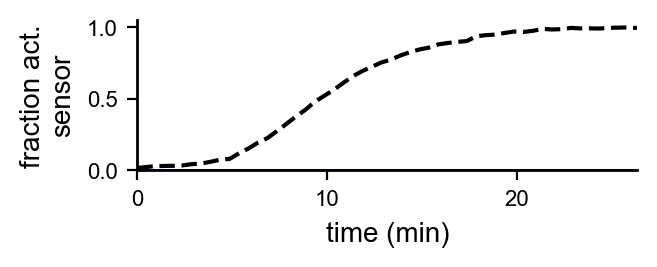

In [101]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MM_default.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
leg.remove()

fig.savefig(savedir + 'prior_pred_MM_default.pdf', bbox_inches='tight', transparent=True)

The above prior predictive densities show that with the current priors and nominals values, the MM model cannot predict ANY sensor activation. This could be because the nominal values for the nonidentifiable parameters are wrong

We will compute prior predictive densities with varying values of the dephosphorylation and phosphorylation rates of the sensor and choose values that give reasonable prior predictive densities.

In [102]:
# vary only kCaMKK
kCaMKKs = [8.1e-4, 8.1e-3, 8.1e-2, 8.1e-1, 8.1e-0, 8.1e1, 8.1e2]
preds_kCaMKK_vary = []

for kCaMKK in kCaMKKs:
    MM_pm_model_updated = construct_pm_model_MM(kCaMKK=kCaMKK)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_kCaMKK_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only kAMPK
kAMPKs = [1.92e-5, 1.92e-4, 1.92e-3, 1.92e-2, 1.92e-1, 1.92e0, 1.92e1, 1.92e2]
preds_kAMPK_vary = []

for kAMPK in kAMPKs:
    MM_pm_model_updated = construct_pm_model_MM(kAMPK=kAMPK)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_kAMPK_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only KmAMPK
KmAMPKs = [8.49e-3, 8.49e-2, 8.49e-1, 8.49e0, 8.49e1, 8.49e2, 8.49e3]
preds_KmAMPK_vary = []

for KmAMPK in KmAMPKs:
    MM_pm_model_updated = construct_pm_model_MM(KmAMPK=KmAMPK)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_KmAMPK_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only kPP1
kPP1s = [1.1e-6, 1.1e-5, 1.1e-4, 1.1e-3, 1.1e-2, 1.1e-1, 1.1e0, 1.1e1]
preds_kPP1_vary = []

for kPP1 in kPP1s:
    MM_pm_model_updated = construct_pm_model_MM(kPP1=kPP1)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_kPP1_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only KmPP1
KmPP1s = [6.7e-4, 6.7e-3, 6.7e-2, 6.7e-1, 6.7e0, 6.7e1, 6.7e2]
preds_KmPP1_vary = []
for KmPP1 in KmPP1s:
    MM_pm_model_updated = construct_pm_model_MM(KmPP1=KmPP1)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_KmPP1_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kO

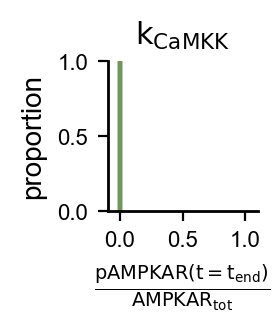

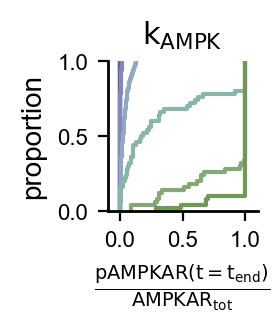

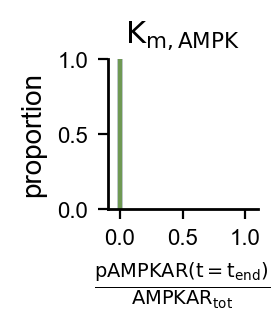

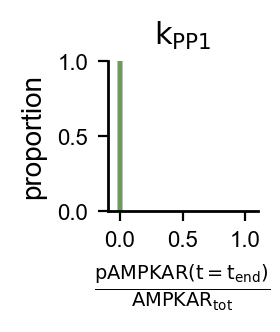

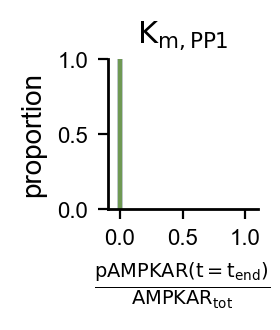

In [103]:
# plot histograms of pAMPKAR(t=tend)/AMPKAR_tot for the four varying parameters
fig, ax = get_sized_fig_ax(0.75,0.75)
fig0, ax0 = get_sized_fig_ax(0.75,0.75)
fig1, ax1 = get_sized_fig_ax(0.75,0.75)
fig2, ax2 = get_sized_fig_ax(0.75,0.75)
fig3, ax3 = get_sized_fig_ax(0.75,0.75)

ax.set_title(r'$k_{CaMKK}$', fontweight='regular', fontsize=11.0)
ax0.set_title(r'$k_{AMPK}$', fontweight='regular', fontsize=11.0)
ax1.set_title(r'$K_{m,AMPK}$', fontweight='regular', fontsize=11.0)
ax2.set_title(r'$k_{PP1}$', fontweight='regular', fontsize=11.0)
ax3.set_title(r'$K_{m,PP1}$', fontweight='regular', fontsize=11.0)

# kCaMKK
for i in range(len(kCaMKKs)):
    color = mb.met_brew(name="VanGogh1", n=len(kCaMKKs), brew_type='continuous')[i]
    if kCaMKKs[i] == 8.1e-4:
        label = f'{kCaMKKs[i]}*'
    else:
        label=f'{kCaMKKs[i]}'
    sns.ecdfplot(jnp.squeeze(preds_kCaMKK_vary[i][:,0,-1]), ax=ax, color=color, label=label)

# kAMPK
for i in range(len(kAMPKs)):
    color = mb.met_brew(name="VanGogh1", n=len(kAMPKs), brew_type='continuous')[i]
    if kAMPKs[i] == 1.92e-5:
        label = f'{kAMPKs[i]}*'
    else:
        label=f'{kAMPKs[i]}'
    sns.ecdfplot(jnp.squeeze(preds_kAMPK_vary[i][:,0,-1]), ax=ax0, color=color, label=label)

# KmAMPK
for i in range(len(KmAMPKs)):
    color = mb.met_brew(name="VanGogh1", n=len(KmAMPKs), brew_type='continuous')[i]
    if KmAMPKs[i] == 8.49e-2:
        label = f'{KmAMPKs[i]}*'
    else:
        label=f'{KmAMPKs[i]}'
    sns.ecdfplot(jnp.squeeze(preds_KmAMPK_vary[i][:,0,-1]), ax=ax1, color=color, label=label)

# kPP1
for i in range(len(kPP1s)):
    color = mb.met_brew(name="VanGogh1", n=len(kPP1s), brew_type='continuous')[i]
    if kPP1s[i] == 1.1e-4:
        label = f'{kPP1s[i]}*'
    else:
        label=f'{kPP1s[i]}'
    sns.ecdfplot(jnp.squeeze(preds_kPP1_vary[i][:,0,-1]), ax=ax2, color=color, label=label)

# KmPP1
for i in range(len(KmPP1s)):
    color = mb.met_brew(name="VanGogh1", n=len(KmPP1s), brew_type='continuous')[i]
    if KmPP1s[i] == 6.7e-2:
        label = f'{KmPP1s[i]}*'
    else:
        label=f'{KmPP1s[i]}'
    sns.ecdfplot(jnp.squeeze(preds_KmPP1_vary[i][:,0,-1]), ax=ax3, color=color, label=label)

ax.legend(title=r'$k_{CaMKK}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax0.legend(title=r'$k_{AMPK}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax1.legend(title=r'$K_{m,AMPK}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax2.legend(title=r'$k_{PP1}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax3.legend(title=r'$K_{m,PP1}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)

ax.set_xlim([-0.1,1.1])
ax0.set_xlim([-0.1,1.1])
ax1.set_xlim([-0.1,1.1])
ax2.set_xlim([-0.1,1.1])
ax3.set_xlim([-0.1,1.1])

ax.set_ylabel('proportion', fontsize=10.0)
ax0.set_ylabel('proportion', fontsize=10.0)
ax1.set_ylabel('proportion', fontsize=10.0)
ax2.set_ylabel('proportion', fontsize=10.0)
ax3.set_ylabel('proportion', fontsize=10.0)

ax.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax0.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax1.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax2.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax3.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)

ax.set_xticks([0, 0.5, 1.0])
ax0.set_xticks([0, 0.5, 1.0])
ax1.set_xticks([0, 0.5, 1.0])
ax2.set_xticks([0, 0.5, 1.0])
ax3.set_xticks([0, 0.5, 1.0])
ax.set_yticks([0, 0.5, 1.0])
ax0.set_yticks([0, 0.5, 1.0])
ax1.set_yticks([0, 0.5, 1.0])
ax2.set_yticks([0, 0.5, 1.0])
ax3.set_yticks([0, 0.5, 1.0])

ax.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax0.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax1.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax2.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax3.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax0.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax1.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax2.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax3.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_kCaMKK_legend.pdf')
leg.remove()

leg = ax0.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_kAMPK_legend.pdf')
leg.remove()

leg = ax1.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_KmAMPK_legend.pdf')
leg.remove()

leg = ax2.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_kPP1_legend.pdf')
leg.remove()

leg = ax3.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_var_KmPP1_legend.pdf')
leg.remove()

fig.savefig(savedir + 'prior_pred_MM_var_kCaMKK.pdf', bbox_inches='tight', transparent=True)
fig0.savefig(savedir + 'prior_pred_MM_var_kAMPK.pdf', bbox_inches='tight', transparent=True)
fig1.savefig(savedir + 'prior_pred_MM_var_KmAMPK.pdf', bbox_inches='tight', transparent=True)
fig2.savefig(savedir + 'prior_pred_MM_var_kPP1.pdf', bbox_inches='tight', transparent=True)
fig3.savefig(savedir + 'prior_pred_MM_var_KmPP1.pdf', bbox_inches='tight', transparent=True)

kAMPK makes a big difference. Choose kAMPK = 1.92 and repeat for other parameters.

In [104]:
# vary only kCaMKK
kCaMKKs = [8.1e-4, 8.1e-3, 8.1e-2, 8.1e-1, 8.1e-0, 8.1e1, 8.1e2]
preds_kCaMKK_vary = []

for kCaMKK in kCaMKKs:
    MM_pm_model_updated = construct_pm_model_MM(kCaMKK=kCaMKK, kAMPK=0.192)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_kCaMKK_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only KmAMPK
KmAMPKs = [8.49e-3, 8.49e-2, 8.49e-1, 8.49e0, 8.49e1, 8.49e2, 8.49e3]
preds_KmAMPK_vary = []

for KmAMPK in KmAMPKs:
    MM_pm_model_updated = construct_pm_model_MM(KmAMPK=KmAMPK, kAMPK=0.192)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_KmAMPK_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only kPP1
kPP1s = [1.1e-6, 1.1e-5, 1.1e-4, 1.1e-3, 1.1e-2, 1.1e-1, 1.1e0, 1.1e1]
preds_kPP1_vary = []

for kPP1 in kPP1s:
    MM_pm_model_updated = construct_pm_model_MM(kPP1=kPP1, kAMPK=0.192)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_kPP1_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

# vary only KmPP1
KmPP1s = [6.7e-4, 6.7e-3, 6.7e-2, 6.7e-1, 6.7e0, 6.7e1, 6.7e2]
preds_KmPP1_vary = []
for KmPP1 in KmPP1s:
    MM_pm_model_updated = construct_pm_model_MM(KmPP1=KmPP1, kAMPK=0.192)
    with MM_pm_model_updated:
        prior_pred_MM_updated = pm.sample_prior_predictive(samples=50)
    preds_KmPP1_vary.append(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]
Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kO

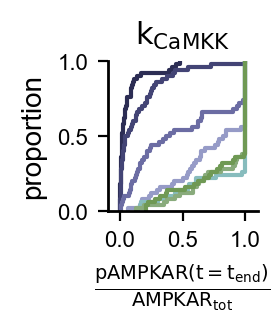

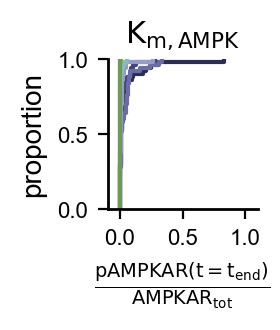

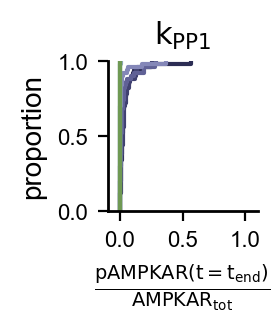

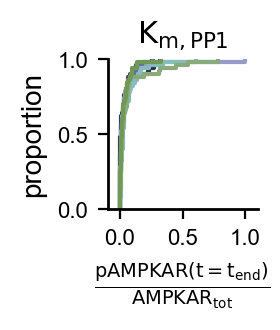

In [105]:
# plot histograms of pAMPKAR(t=tend)/AMPKAR_tot for the four varying parameters
fig, ax = get_sized_fig_ax(0.75,0.75)
fig0, ax0 = get_sized_fig_ax(0.75,0.75)
fig1, ax1 = get_sized_fig_ax(0.75,0.75)
fig2, ax2 = get_sized_fig_ax(0.75,0.75)

ax.set_title(r'$k_{CaMKK}$', fontweight='regular', fontsize=11.0)
ax0.set_title(r'$K_{m,AMPK}$', fontweight='regular', fontsize=11.0)
ax1.set_title(r'$k_{PP1}$', fontweight='regular', fontsize=11.0)
ax2.set_title(r'$K_{m,PP1}$', fontweight='regular', fontsize=11.0)

# kCaMKK
for i in range(len(kCaMKKs)):
    color = mb.met_brew(name="VanGogh1", n=len(kCaMKKs), brew_type='continuous')[i]
    if kCaMKKs[i] == 8.1e-4:
        label = f'{kCaMKKs[i]}*'
    else:
        label=f'{kCaMKKs[i]}'
    sns.ecdfplot(jnp.squeeze(preds_kCaMKK_vary[i][:,0,-1]), ax=ax, color=color, label=label)

# KmAMPK
for i in range(len(KmAMPKs)):
    color = mb.met_brew(name="VanGogh1", n=len(KmAMPKs), brew_type='continuous')[i]
    if KmAMPKs[i] == 8.49e-2:
        label = f'{KmAMPKs[i]}*'
    else:
        label=f'{KmAMPKs[i]}'
    sns.ecdfplot(jnp.squeeze(preds_KmAMPK_vary[i][:,0,-1]), ax=ax0, color=color, label=label)

# kPP1
for i in range(len(kPP1s)):
    color = mb.met_brew(name="VanGogh1", n=len(kPP1s), brew_type='continuous')[i]
    if kPP1s[i] == 1.1e-4:
        label = f'{kPP1s[i]}*'
    else:
        label=f'{kPP1s[i]}'
    sns.ecdfplot(jnp.squeeze(preds_kPP1_vary[i][:,0,-1]), ax=ax1, color=color, label=label)

# KmPP1
for i in range(len(KmPP1s)):
    color = mb.met_brew(name="VanGogh1", n=len(KmPP1s), brew_type='continuous')[i]
    if KmPP1s[i] == 6.7e-2:
        label = f'{KmPP1s[i]}*'
    else:
        label=f'{KmPP1s[i]}'
    sns.ecdfplot(jnp.squeeze(preds_KmPP1_vary[i][:,0,-1]), ax=ax2, color=color, label=label)


ax0.legend(title=r'$K_{m,AMPK}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax.legend(title=r'$k_{CaMKK}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax1.legend(title=r'$k_{PP1}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)
ax2.legend(title=r'$K_{m,PP1}$', bbox_to_anchor=(3, 1), loc='upper right', fontsize=8)

ax.set_xlim([-0.1,1.1])
ax0.set_xlim([-0.1,1.1])
ax1.set_xlim([-0.1,1.1])
ax2.set_xlim([-0.1,1.1])

ax.set_ylabel('proportion', fontsize=10.0)
ax0.set_ylabel('proportion', fontsize=10.0)
ax1.set_ylabel('proportion', fontsize=10.0)
ax2.set_ylabel('proportion', fontsize=10.0)

ax.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax0.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax1.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)
ax2.set_xlabel(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=10.0)

ax.set_xticks([0, 0.5, 1.0])
ax0.set_xticks([0, 0.5, 1.0])
ax1.set_xticks([0, 0.5, 1.0])
ax2.set_xticks([0, 0.5, 1.0])
ax.set_yticks([0, 0.5, 1.0])
ax0.set_yticks([0, 0.5, 1.0])
ax1.set_yticks([0, 0.5, 1.0])
ax2.set_yticks([0, 0.5, 1.0])

ax.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax0.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax1.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax2.set_xticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax0.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax1.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)
ax2.set_yticklabels(['0.0', '0.5', '1.0'], fontsize=8.0)

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_fix_kAMPK_var_kCaMKK_legend.pdf')
leg.remove()

leg = ax0.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_fix_kAMPK_var_KmAMPK_legend.pdf')
leg.remove()

leg = ax1.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_fix_kAMPK_var_kPP1_legend.pdf')
leg.remove()

leg = ax2.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_fix_kAMPK_var_KmPP1_legend.pdf')
leg.remove()

fig.savefig(savedir + 'prior_pred_MM_fix_kAMPK_var_kCaMKK.pdf', bbox_inches='tight', transparent=True)
fig0.savefig(savedir + 'prior_pred_MM_fix_kAMPK_var_KmAMPK.pdf', bbox_inches='tight', transparent=True)
fig1.savefig(savedir + 'prior_pred_MM_fix_kAMPK_var_kPP1.pdf', bbox_inches='tight', transparent=True)
fig2.savefig(savedir + 'prior_pred_MM_fix_kAMPK_var_KmPP1.pdf', bbox_inches='tight', transparent=True)

Choose kCaMKK = 0.81, KmAMPK = 8.5e-3

Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


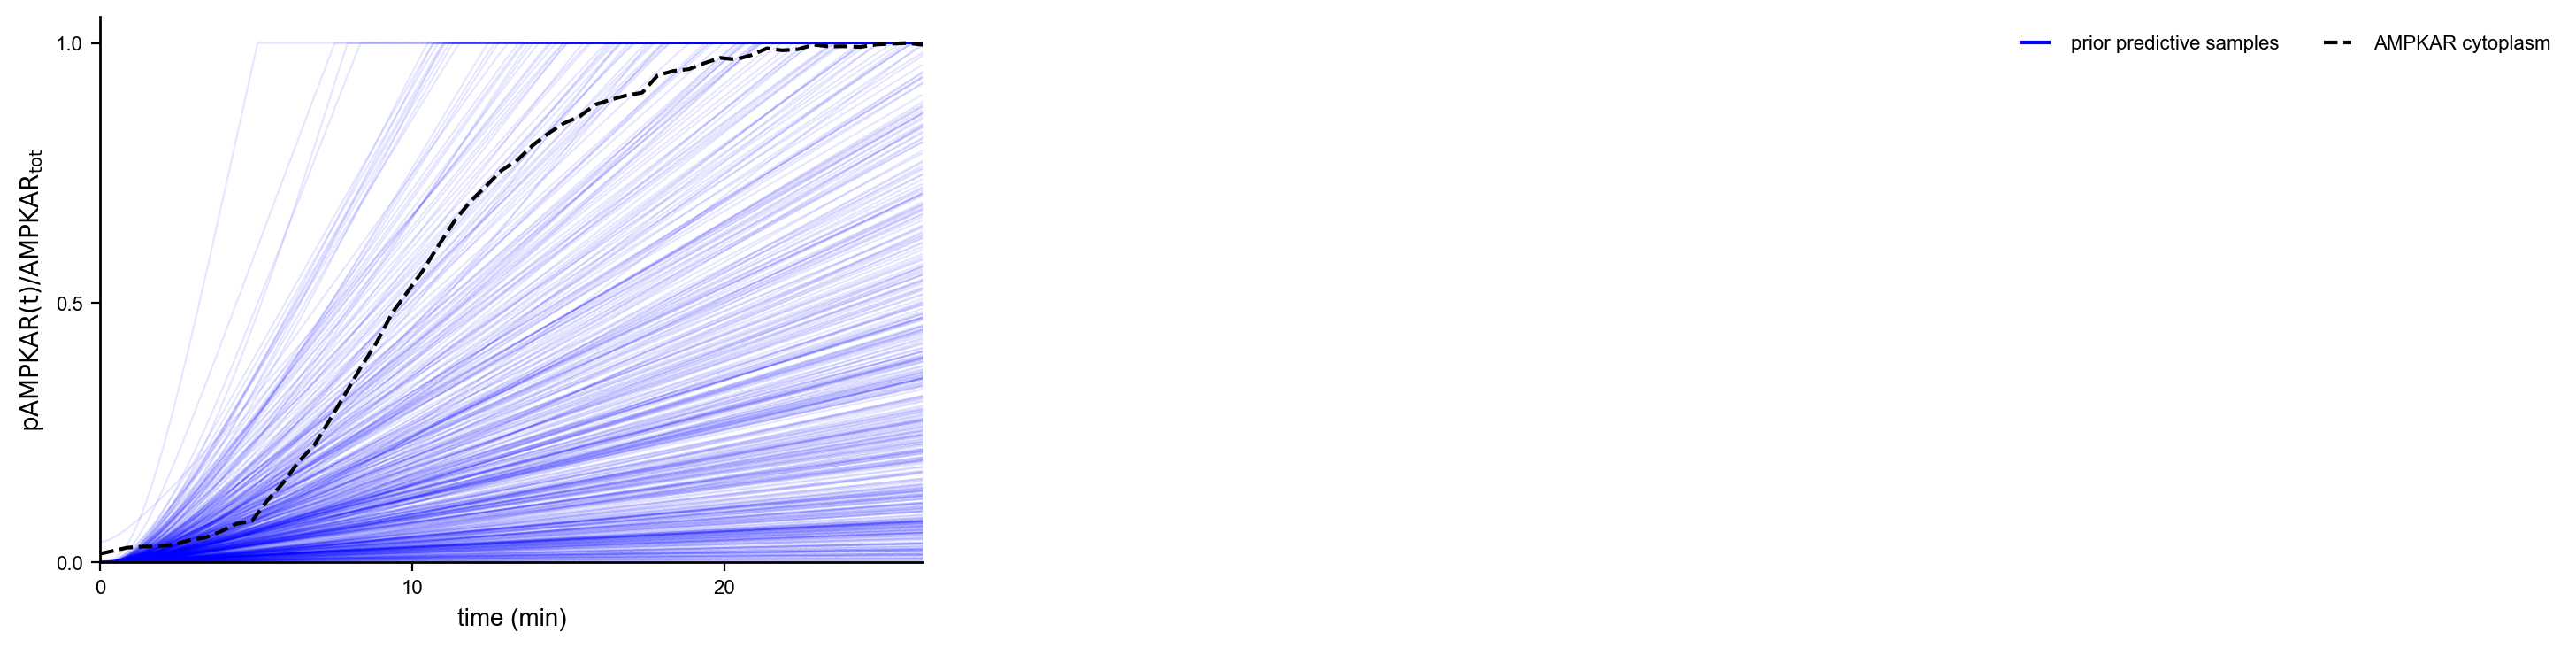

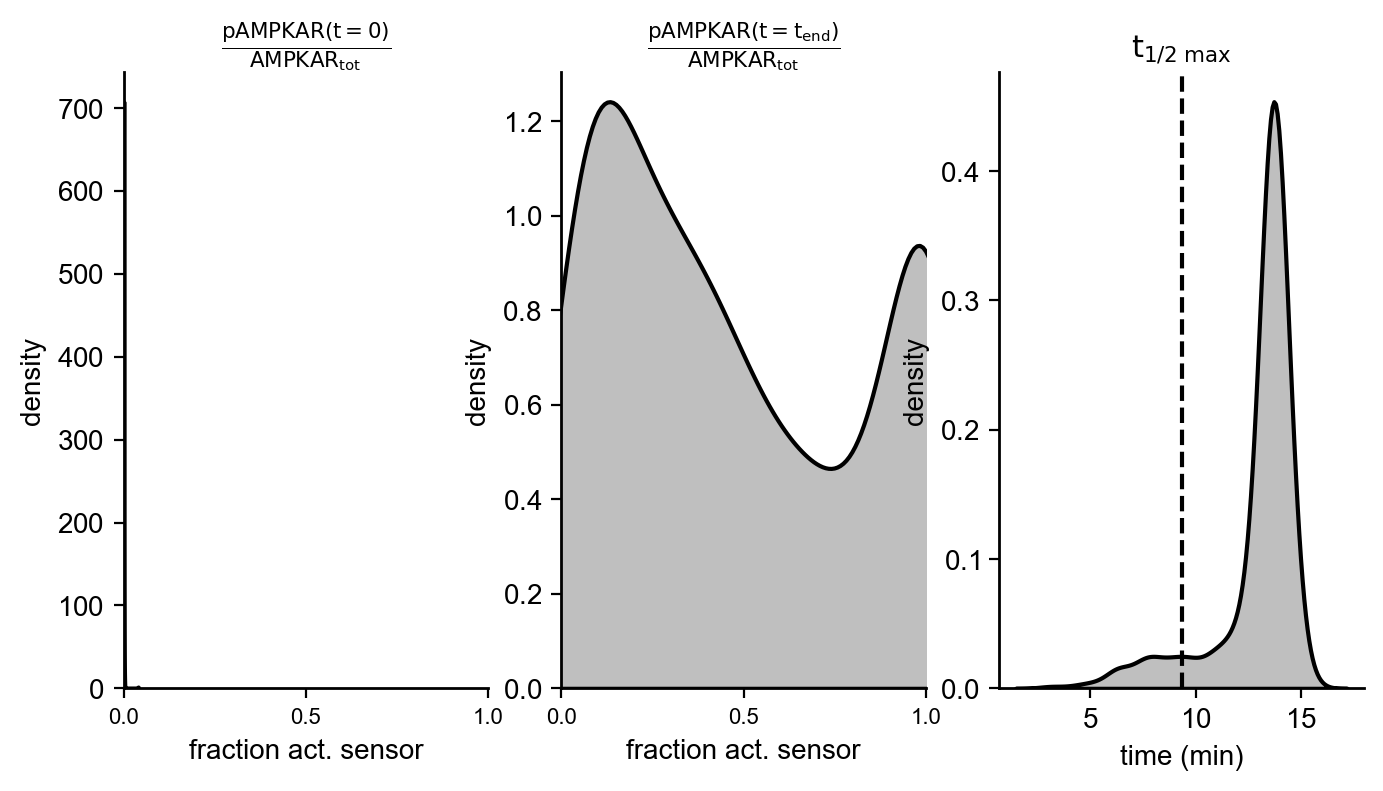

In [106]:
MM_pm_model_updated = construct_pm_model_MM(kCaMKK=0.081, KmAMPK=8.49e-3, kAMPK=0.192)
with MM_pm_model_updated:
    prior_pred_MM_updated = pm.sample_prior_predictive(samples=500)


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_func_trajectories(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:], ax)

plot_func_densities(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:])

This looks better, but there are still many slow and low trajectories. Refine more

In [107]:
def construct_pm_model_MM_updated(kOffAMP_mu=MM_info['prior_params']['kOffAMP']['mu'],
            kOffAMP_sigma=MM_info['prior_params']['kOffAMP']['sigma'],
            kOffADP_mu=MM_info['prior_params']['kOffADP']['mu'],
            kOffADP_sigma=MM_info['prior_params']['kOffADP']['sigma'],
            kOffATP_mu=MM_info['prior_params']['kOffATP']['mu'],
            kOffATP_sigma=MM_info['prior_params']['kOffATP']['sigma'],
            Km_CaMKK_mu=MM_info['prior_params']['KmCaMKK']['mu'],
            Km_CaMKK_sigma=MM_info['prior_params']['KmCaMKK']['sigma'],
            kLKB1_mu=MM_info['prior_params']['kLKB1']['mu'],
            kLKB1_sigma=MM_info['prior_params']['kLKB1']['sigma'],
            KmLKB1_mu=MM_info['prior_params']['KmLKB1']['mu'],
            KmLKB1_sigma=MM_info['prior_params']['KmLKB1']['sigma'],
            kPP_mu=MM_info['prior_params']['kPP']['mu'],
            kPP_sigma=MM_info['prior_params']['kPP']['sigma'],
            KmPP_mu=MM_info['prior_params']['KmPP']['mu'],
            KmPP_sigma=MM_info['prior_params']['KmPP']['sigma'],
            std_mult=0.001
            ):
    # construct pymc model
    with pm.Model() as model_MM:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0) 
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kCaMKK = pm.Data('kCaMKK', 0.081)
        KmCaMKK = pm.LogNormal('KmCaMKK', mu=Km_CaMKK_mu, sigma=Km_CaMKK_sigma)
        kLKB1 = pm.LogNormal('kLKB1', mu=kLKB1_mu, sigma=kLKB1_sigma)
        KmLKB1 = pm.LogNormal('KmLKB1', mu=KmLKB1_mu, sigma=KmLKB1_sigma)
        kPP = pm.LogNormal('kPP', mu=kPP_mu, sigma=kPP_sigma)
        KmPP = pm.LogNormal('KmPP', mu=KmPP_mu, sigma=KmPP_sigma)
        kAMPK = pm.Data('pAMPK',0.192)
        KmAPK = pm.Data('KmAMPK', 8.5e-3)
        kPP1 = pm.Data('pPP1', 1.1e-4)
        KmPP1 = pm.Data('KmPP1', 6.7e-2)
        # CaMKKtot = pm.Data('CaMKKtot', 1.0)
        LKB1tot = pm.Data('LKB1tot', 1.0)
        PPtot = pm.Data('PPtot', 1.0)
        PP1tot = pm.Data('PP1tot', 1.0)
        kOnCaM = pm.Data('kOnCaM', MM_info['nominal_params']['kOnCaM'])
        kOffCaM = pm.Data('kOffCaM', MM_info['nominal_params']['kOffCaM'])
        kPhosCaM = pm.Data('kPhosCaM', MM_info['nominal_params']['kPhosCaM'])
        KmCaM = pm.Data('KmCaM', MM_info['nominal_params']['KmCaM'])
        kDephosCaMKK = pm.Data('kDephosCaMKK', MM_info['nominal_params']['kDephosCaMKK'])

        # kCaMKK=8.1, KmAMPK=8.5e-3, kAMPK=1.92, kPP1=1.1e-4, KmPP1=6.7e-2

        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, 
                  kCaMKK, KmCaMKK, kLKB1, KmLKB1, kPP, KmPP, 
                  kAMPK, KmAPK, kPP1, KmPP1, LKB1tot, PPtot, PP1tot,
                  kOnCaM, kOffCaM, kPhosCaM, KmCaM, kDephosCaMKK]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MM(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model_MM

pz.predictive_explorer(construct_pm_model_MM_updated, plot_func=plot_func_trajectories, samples=200)

This looks much better. The main changes were to change the AXP off rate priors to match those of the MA model. We additionally rounded the other prior parameters to nearest 1, 0.5 or .25 and set all standard deviations to 1.0.

In [108]:
updated_prior_params_MM = {
    'kOffAMP':    {'mu': -4.5,  'sigma': 1.0},
    'kOffADP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffATP':    {'mu': -5.5,  'sigma': 1.0},
    'KmCaMKK':    {'mu': -1.0,  'sigma': 1.0},
    'kLKB1':      {'mu': -2.0,   'sigma': 1.0},
    'KmLKB1':     {'mu': 6.0,  'sigma': 1.0},
    'kPP':        {'mu': 0.0,  'sigma': 1.0},
    'KmPP':       {'mu': 0.0,  'sigma': 3.0}
}

MM_pm_model_updated = construct_pm_model_MM_updated(
    kOffAMP_mu=updated_prior_params_MM['kOffAMP']['mu'],
    kOffAMP_sigma=updated_prior_params_MM['kOffAMP']['sigma'],
    kOffADP_mu=updated_prior_params_MM['kOffADP']['mu'],
    kOffADP_sigma=updated_prior_params_MM['kOffADP']['sigma'],
    kOffATP_mu=updated_prior_params_MM['kOffATP']['mu'],
    kOffATP_sigma=updated_prior_params_MM['kOffATP']['sigma'],
    Km_CaMKK_mu=updated_prior_params_MM['KmCaMKK']['mu'],
    Km_CaMKK_sigma=updated_prior_params_MM['KmCaMKK']['sigma'],
    kLKB1_mu=updated_prior_params_MM['kLKB1']['mu'],
    kLKB1_sigma=updated_prior_params_MM['kLKB1']['sigma'],
    KmLKB1_mu=updated_prior_params_MM['KmLKB1']['mu'],
    KmLKB1_sigma=updated_prior_params_MM['KmLKB1']['sigma'],
    kPP_mu=updated_prior_params_MM['kPP']['mu'],
    kPP_sigma=updated_prior_params_MM['kPP']['sigma'],
    std_mult=0.001)

with MM_pm_model_updated:
    prior_pred_MM_updated = pm.sample_prior_predictive(samples=500)

Sampling: [KmCaMKK, KmLKB1, KmPP, kLKB1, kOffADP, kOffAMP, kOffATP, kPP, like]


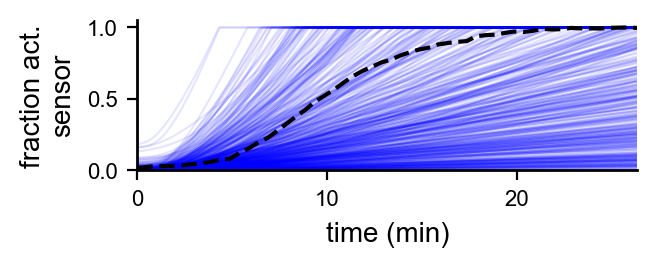

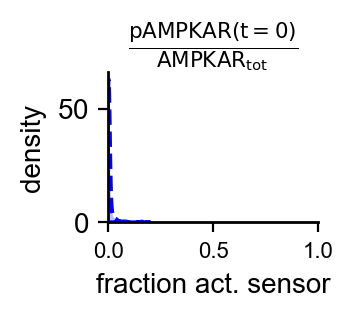

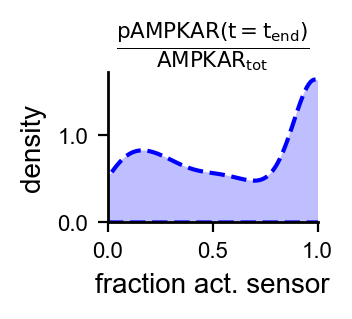

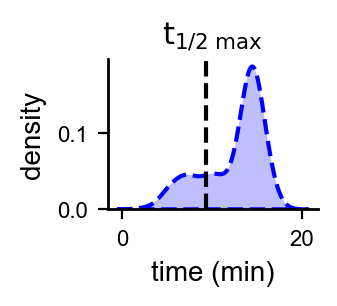

In [109]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MM_updated_legend.pdf')
leg.remove()
# fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MM_updated.pdf', bbox_inches='tight', transparent=True)

fig_orig_mm_ratio_basal, ax_orig_mm_ratio_basal = get_sized_fig_ax(1.05, 0.75)
fig_orig_mm_ratio, ax_orig_mm_ratio = get_sized_fig_ax(1.05, 0.75)
fig_orig_mm_t_half_max, ax_orig_mm_t_half_max = get_sized_fig_ax(1.05, 0.75)

axs = [ax_orig_mm_ratio_basal, ax_orig_mm_ratio, ax_orig_mm_t_half_max]
figs= [fig_orig_mm_ratio_basal, fig_orig_mm_ratio, fig_orig_mm_t_half_max]

# plot_func_densities(prior_pred_MM_default.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs, plot_data=False)
plot_func_densities(prior_pred_MM_updated.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs, linestyle='--', color='b')

leg = axs[0].legend(['orginal', 'updated'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)
leg.remove()
leg = axs[1].legend(['orginal', 'updated'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)
leg.remove()
axs[2].legend(['refined priors', 'cytoplasm'], loc='upper right', ncols=2, bbox_to_anchor=(3, 1.0), fontsize=8.0)

leg = axs[2].get_legend()
export_legend(leg, savedir + 'prior_pred_stats_MM_updated_legend.pdf')
leg.remove()

# axs[0].set_yticks([0, 5])
# axs[0].set_yticklabels(['0.0', '5.0'], fontsize=8.0)
axs[1].set_yticks([0, 1])
axs[1].set_yticklabels(['0.0', '1.0'], fontsize=8.0)
axs[2].set_yticks([0, 0.1])
axs[2].set_yticklabels(['0.0', '0.1'], fontsize=8.0)

axs[2].set_xticks([0,20])
axs[2].set_xticklabels(['0', '20'], fontsize=8.0)


figs[0].savefig(savedir + 'prior_pred_MM_updated_ratio_basal.pdf', bbox_inches='tight', transparent=True)
figs[1].savefig(savedir + 'prior_pred_MM_updated_ratio.pdf', bbox_inches='tight', transparent=True)
figs[2].savefig(savedir + 'prior_pred_MM_updated_t_half_max.pdf', bbox_inches='tight', transparent=True)

This looks pretty good. Lets store these priors in the model_info file and compute the HDI

In [110]:
#  95% hdi of updated prior for bounds for GSA
MM_bounds_updated = {}
MM_prior_params_updated = {}
for param in MM_info['params']:
    if param in updated_prior_params_MM.keys():
        # hdi
        bounds = list(pz.LogNormal(mu=updated_prior_params_MM[param]['mu'], sigma=updated_prior_params_MM[param]['sigma']).hdi(0.95, fmt='.8f'))
        MM_bounds_updated[param] = bounds

        # prior params
        MM_prior_params_updated[param] = updated_prior_params_MM[param]
    else:
        MM_bounds_updated[param] = []
        MM_prior_params_updated[param] = {}

# update the model info file with the new bounds
MM_info['param_bounds'] =  MM_bounds_updated
MM_info['prior_params'] = MM_prior_params_updated

# save the updated model info
with open('../models/MM_single.json', 'w') as file:
    json.dump(MM_info, file, indent=4)